Purpose: Look at results of polynomial CAM gene modeling by physiology (*Y. gloriosa*).<br>
Author: Anna Pardo<br>
Date initiated: Mar. 19, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load results for scaled TPM (this is what I used for polynomial modeling by genotype)
res = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/polymodres_scaled_allCAM_byphys.txt",
                 sep="\t",header="infer")
res.head()

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F),Model,GeneID,GeneName,TPM_Type,FDR_p
0,798,666.205896,NaN,NaN,NaN,NaN,polyZT,Yucal.01G165600.v2.1,Ya_bCA1234_1,scaled,NaN
1,786,635.340557,12.0,30.865340,4.141276,0.000003,polyZT*phys,Yucal.01G165600.v2.1,Ya_bCA1234_1,scaled,0.000008
2,792,519.345035,-6.0,115.995521,NaN,NaN,polyZT*treat,Yucal.01G165600.v2.1,Ya_bCA1234_1,scaled,NaN
3,768,476.998296,24.0,42.346739,2.840882,0.000008,polyZT*treat*phys,Yucal.01G165600.v2.1,Ya_bCA1234_1,scaled,0.000022
4,798,797.632736,NaN,NaN,NaN,NaN,polyZT,Yucal.02G112700.v2.1,Ya_bCA1234_2,scaled,NaN


In [4]:
res.dropna(inplace=True)

In [5]:
# find significant results
sigres = res[res["FDR_p"]<0.05]

In [6]:
len(res.index)-len(sigres.index)

47

In [7]:
# drop model polyZT (baseline)
nobase = sigres[sigres["Model"]!="polyZT"]

In [8]:
# create Subgenome column
sg = []
for i in list(sigres["GeneID"]):
    if i.startswith("Yucal"):
        sg.append("Ya")
    else:
        sg.append("Yf")

In [9]:
len(res["GeneName"].unique())

70

In [10]:
len(sigres["GeneName"].unique())

58

In [18]:
# for each gene that does have significant results: make a table showing which model(s) were significant/their FDR p-values
## (this can go in the supplement for the paper)
dfdict = {"Gene Name":[],"Gene ID":[],"ZT*Treatment":[],"ZT*Physiology":[],"ZT*Treatment*Physiology":[]}
for i in sigres["GeneName"].unique():
    dfdict['Gene Name'].append(i)
    df = sigres[sigres["GeneName"]==i]
    #print(df)
    dfdict['Gene ID'].append(df["GeneID"].unique()[0])
    
    if "polyZT*phys" in list(df["Model"]):
        dfdict['ZT*Physiology'].append(df.loc[df['Model'] == "polyZT*phys", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Physiology'].append("not significant")
        
    if "polyZT*treat" in list(df["Model"]):
        dfdict['ZT*Treatment'].append(df.loc[df['Model'] == "polyZT*treat", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Treatment'].append("not significant")
        
    if "polyZT*treat*phys" in list(df["Model"]):
        dfdict['ZT*Treatment*Physiology'].append(df.loc[df['Model'] == "polyZT*treat*phys", 'FDR_p'].iloc[0])
    else:
        dfdict['ZT*Treatment*Physiology'].append("not significant")

In [19]:
genesigs = pd.DataFrame(dfdict)
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology
0,Ya_bCA1234_1,Yucal.01G165600.v2.1,not significant,0.000008,0.000022
1,Ya_bCA5_1,Yucal.04G001000.v2.1,0.000263,0.000258,0.015728
2,Ya_bCA5_2,Yucal.07G000800.v2.1,0.002504,0.001059,0.034143
3,Ya_NAD-MDH-cp_2,Yucal.04G064300.v2.1,0.0,0.0,0.0
4,Ya_NAD-MDH-cp_3,Yucal.05G198500.v2.1,0.000048,0.000547,0.011559


In [21]:
# save this table
genesigs.to_csv("./camgenes_polymod_byphys_pvals.csv",sep=",",header=True,index=False)

In [22]:
# visualize significant p-values
## to do so, add NA in place of not significant
genesigs.loc[genesigs["ZT*Physiology"]=="not significant","ZT*Physiology"] = np.nan

In [24]:
genesigs.loc[genesigs["ZT*Treatment"]=="not significant","ZT*Treatment"] = np.nan
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology
0,Ya_bCA1234_1,Yucal.01G165600.v2.1,NaN,0.000008,0.000022
1,Ya_bCA5_1,Yucal.04G001000.v2.1,0.000263,0.000258,0.015728
2,Ya_bCA5_2,Yucal.07G000800.v2.1,0.002504,0.001059,0.034143
3,Ya_NAD-MDH-cp_2,Yucal.04G064300.v2.1,0.0,0.0,0.0
4,Ya_NAD-MDH-cp_3,Yucal.05G198500.v2.1,0.000048,0.000547,0.011559


In [25]:
genesigs.loc[genesigs["ZT*Treatment*Physiology"]=="not significant","ZT*Treatment*Physiology"] = np.nan

In [27]:
# load CAM gene annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [30]:
# add gene family & subgenome info
genesigs = genesigs.merge(cam[["gene_abbr","gene_abbr_unique","GeneID","subgenome"]].rename(columns={"GeneID":"Gene ID",
                                                                                        "gene_abbr_unique":"Gene Name",
                                                                                        "gene_abbr":"Gene Family"}))

In [31]:
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,subgenome
0,Ya_bCA1234_1,Yucal.01G165600.v2.1,NaN,0.000008,0.000022,bCA1234,Ya
1,Ya_bCA5_1,Yucal.04G001000.v2.1,0.000263,0.000258,0.015728,bCA5,Ya
2,Ya_bCA5_2,Yucal.07G000800.v2.1,0.002504,0.001059,0.034143,bCA5,Ya
3,Ya_NAD-MDH-cp_2,Yucal.04G064300.v2.1,0.0,0.0,0.0,NAD-MDH-cp,Ya
4,Ya_NAD-MDH-cp_3,Yucal.05G198500.v2.1,0.000048,0.000547,0.011559,NAD-MDH-cp,Ya


In [32]:
# re-format long
def long_reform(colname,data=genesigs):
    sub = data[["Gene Family","Gene Name","Gene ID","subgenome",colname]]
    sub["Model"] = colname
    sub.rename(columns={colname:"FDR_p"},inplace=True)
    return sub

In [34]:
dfl = []
for c in genesigs.columns:
    if c.startswith("ZT"):
        dfl.append(long_reform(c))
gslong = pd.concat(dfl)
gslong.head()

/tmp/ipykernel_31611/2828142950.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["Model"] = colname
/tmp/ipykernel_31611/2828142950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub.rename(columns={colname:"FDR_p"},inplace=True)
/tmp/ipykernel_31611/2828142950.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

,Gene Family,Gene Name,Gene ID,subgenome,FDR_p,Model
0,bCA1234,Ya_bCA1234_1,Yucal.01G165600.v2.1,Ya,NaN,ZT*Treatment
1,bCA5,Ya_bCA5_1,Yucal.04G001000.v2.1,Ya,0.000263,ZT*Treatment
2,bCA5,Ya_bCA5_2,Yucal.07G000800.v2.1,Ya,0.002504,ZT*Treatment
3,NAD-MDH-cp,Ya_NAD-MDH-cp_2,Yucal.04G064300.v2.1,Ya,0.0,ZT*Treatment
4,NAD-MDH-cp,Ya_NAD-MDH-cp_3,Yucal.05G198500.v2.1,Ya,0.000048,ZT*Treatment


In [36]:
gslong.dropna(inplace=True)

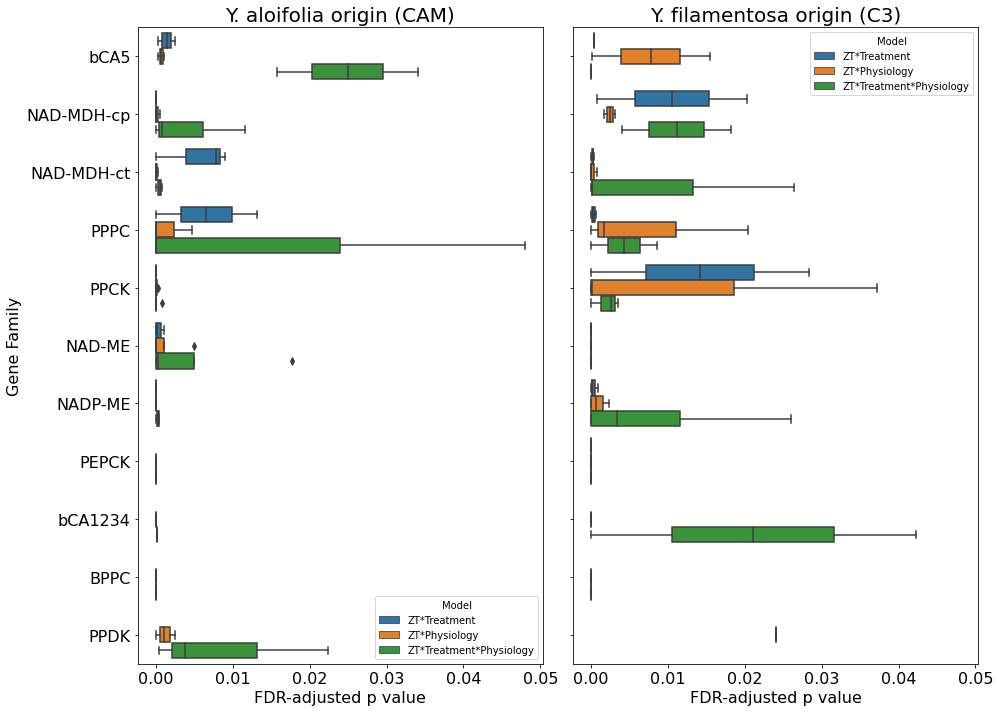

In [47]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharex=True,sharey=True)
sns.boxplot(ax=ax[0],data=gslong[gslong["subgenome"]=="Ya"],y="Gene Family",x="FDR_p",hue="Model")
ax[0].set_title("Y. aloifolia origin (CAM)",fontsize=20)
ax[0].tick_params(which="both",labelsize=16)
ax[0].set_ylabel("Gene Family",fontsize=16)
ax[0].set_xlabel("FDR-adjusted p value",fontsize=16)

sns.boxplot(ax=ax[1],data=gslong[gslong["subgenome"]=="Yf"],y="Gene Family",x="FDR_p",hue="Model")
ax[1].set_title("Y. filamentosa origin (C3)",fontsize=20)
ax[1].tick_params(which="both",labelsize=16)
ax[1].set_ylabel("")
ax[1].set_xlabel("FDR-adjusted p value",fontsize=16)

fig.tight_layout()

plt.savefig("./camgenes_polymod_byphys_pvals.png",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_polymod_byphys_pvals.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_polymod_byphys_pvals.svg",dpi=200,bbox_inches="tight")

In [49]:
# look at just the three gene families of interest for the poster: BPPC, PPPC, PPCK
genesigs.head()

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,subgenome
0,Ya_bCA1234_1,Yucal.01G165600.v2.1,NaN,0.000008,0.000022,bCA1234,Ya
1,Ya_bCA5_1,Yucal.04G001000.v2.1,0.000263,0.000258,0.015728,bCA5,Ya
2,Ya_bCA5_2,Yucal.07G000800.v2.1,0.002504,0.001059,0.034143,bCA5,Ya
3,Ya_NAD-MDH-cp_2,Yucal.04G064300.v2.1,0.0,0.0,0.0,NAD-MDH-cp,Ya
4,Ya_NAD-MDH-cp_3,Yucal.05G198500.v2.1,0.000048,0.000547,0.011559,NAD-MDH-cp,Ya


In [50]:
genesigs[genesigs["Gene Family"]=="BPPC"]

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,subgenome
10,Ya_BPPC_1,Yucal.07G108300.v2.1,NaN,0.0,0.0,BPPC,Ya
11,Ya_BPPC_2,Yucal.07G108400.v2.1,NaN,0.0,0.0,BPPC,Ya
12,Ya_BPPC_3,Yucal.07G108500.v2.1,NaN,0.0,0.0,BPPC,Ya
42,Yf_BPPC,YufilH1044442m.g,NaN,0.0,0.0,BPPC,Yf


In [51]:
genesigs[genesigs["Gene Family"]=="PPPC"]

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,subgenome
13,Ya_PPPC_2,Yucal.06G042800.v2.1,NaN,0.004705,0.047974,PPPC,Ya
14,Ya_PPPC_3,Yucal.07G056400.v2.1,0.0,0.0,0.000003,PPPC,Ya
15,Ya_PPPC_4,Yucal.21G047000.v2.1,0.013127,0.0,0.0,PPPC,Ya
43,Yf_PPPC_2,YufilH1038083m.g,NaN,0.020413,NaN,PPPC,Yf
44,Yf_PPPC_3,YufilH1043280m.g,0.0,0.0,0.0,PPPC,Yf
45,Yf_PPPC_4,YufilH1082305m.g,0.000582,0.001649,0.008555,PPPC,Yf


In [52]:
genesigs[genesigs["Gene Family"]=="PPCK"]

,Gene Name,Gene ID,ZT*Treatment,ZT*Physiology,ZT*Treatment*Physiology,Gene Family,subgenome
16,Ya_PPCK_1,Yucal.03G005000.v2.1,0.0,0.0,0.0,PPCK,Ya
17,Ya_PPCK_2,Yucal.04G178900.v2.1,0.0,0.0,0.0,PPCK,Ya
18,Ya_PPCK_3,Yucal.05G072500.v2.1,NaN,0.000069,0.0,PPCK,Ya
19,Ya_PPCK_4,Yucal.05G072600.v2.1,NaN,0.000318,0.000759,PPCK,Ya
20,Ya_PPCK_7,Yucal.16G055600.v2.1,0.000006,0.0,0.000005,PPCK,Ya
46,Yf_PPCK_1,YufilH1027436m.g,0.000006,0.000059,0.003455,PPCK,Yf
47,Yf_PPCK_2,YufilH1032169m.g,NaN,0.0,0.0,PPCK,Yf
48,Yf_PPCK_3,YufilH1069011m.g,0.028306,NaN,NaN,PPCK,Yf
49,Yf_PPCK_5,YufilH1072272m.g,NaN,0.037165,0.002636,PPCK,Yf
